# `process(StateChange)` — Inducing Targeted Lesions in a Brain-Score Model

Demonstrates the `state_change_fn` mechanism shipped 2026-05-05 — how to ablate units inside a registered Brain-Score model and observe the causal effect on its behavior.

**The pattern:** pick a layer, identify units to lesion, observe the behavioral deficit, restore. This is the same shape Honarmand et al. (2026) used for induced dyslexia in VLMs; we use it here on CLIP for a fast, self-contained demo.

**What you'll see:**
1. CLIP scores three candidate captions for an image (baseline)
2. We ablate the 50 most-active units at `vision_model.encoder.layers.10`
3. Layer activations + caption probabilities both shift
4. `model.reset()` removes the perturbation; behavior returns to baseline

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
from transformers import CLIPProcessor

import brainscore
import brainscore_vision  # registers CLIP
from brainscore_core.model_interface import (
    StateChange, Selection, Perturbation,
)
from brainscore.perturbation import build_pytorch_ablation_fn

/Users/kartik/Brain-Score Unified/core/brainscore_core/metrics/__init__.py:16: FutureWarning: xarray subclass Score should explicitly define __slots__
  class Score(DataAssembly):


## 1. Load the model and wire `state_change_fn`

We pull CLIP from the brain-score registry, then attach a `state_change_fn` to the loaded `BrainScoreModel` instance using the helper `build_pytorch_ablation_fn`. In a benchmark, you'd typically do this inside the model registration; here we do it in the notebook so the wiring is explicit.

In [2]:
bs_model = brainscore.load_model('clip-vit-b-32')
clip_model = bs_model._model  # underlying transformers CLIPModel
processor = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch32')

# Attach the state-change capability. Layer paths in StateChange.target
# will be resolved against the full clip_model object, so both vision
# (vision_model.encoder.layers.X) and text (text_model.encoder.layers.X)
# layers are addressable from this single registration.
bs_model._state_change_fn = build_pytorch_ablation_fn(clip_model)

print(f'state_change_fn wired: {bs_model._state_change_fn is not None}')
print(f'active perturbations: {len(bs_model._active_perturbations)}')

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


state_change_fn wired: True
active perturbations: 0


## 2. Baseline behavior

We give CLIP a synthetic image (a brown square) and three candidate captions. With no perturbation, CLIP should weakly prefer the most literal caption.

In [3]:
# A simple synthetic image: orange-tinted gradient to give CLIP something
# to look at without needing an external file.
img_arr = np.zeros((224, 224, 3), dtype=np.uint8)
for i in range(224):
    img_arr[i, :, 0] = int(120 + (i / 224) * 100)  # red ramp
    img_arr[i, :, 1] = 80
    img_arr[i, :, 2] = 60
img = Image.fromarray(img_arr)

captions = [
    'a photograph of a cat',
    'a sunset over the ocean',
    'a snowy mountain landscape',
    'an abstract orange gradient',
    'a dense forest of green trees',
]

# Move the model to CPU for this demo so inputs and weights stay aligned
# regardless of how the registry loaded it.
clip_model = clip_model.to('cpu').eval()

inputs = processor(images=img, text=captions,
                   return_tensors='pt', padding=True)

def cosine_sims(out):
    """Cosine similarity between (single) image embedding and each text
    embedding. Cleaner than softmax-probabilities for visualizing
    effects: softmax saturates at CLIP's learned temperature.
    """
    img_emb = out.image_embeds / out.image_embeds.norm(dim=-1, keepdim=True)
    txt_emb = out.text_embeds / out.text_embeds.norm(dim=-1, keepdim=True)
    return (img_emb @ txt_emb.T)[0].cpu().numpy()

with torch.no_grad():
    baseline_out = clip_model(**inputs)
baseline_sims = cosine_sims(baseline_out)

print('Baseline image-caption cosine similarities:')
ranked = sorted(zip(baseline_sims, captions), reverse=True)
for sim, cap in ranked:
    print(f'  {sim:+.3f}  {cap}')

Baseline image-caption cosine similarities:
  +0.295  an abstract orange gradient
  +0.221  a dense forest of green trees
  +0.218  a sunset over the ocean
  +0.208  a snowy mountain landscape
  +0.199  a photograph of a cat


## 3. Capture baseline activations at the target layer

We'll ablate at `vision_model.encoder.layers.10` (the layer used as 'IT' in CLIP's region map). To visualize the effect, we need to record activations both before and after the perturbation. We use a manual forward-hook for this — separate from the hook the `state_change_fn` will install.

In [4]:
TARGET_LAYER_PATH = 'vision_model.encoder.layers.10'
target_layer = clip_model.vision_model.encoder.layers[10]

activations = {}

def make_capture(key):
    def hook(_m, _i, output):
        h = output[0] if isinstance(output, tuple) else output
        activations[key] = h.detach().cpu().numpy()
    return hook

h = target_layer.register_forward_hook(make_capture('baseline'))
with torch.no_grad():
    clip_model(**inputs)
h.remove()

print(f'Activations shape (batch, seq_len, hidden_dim): '
      f'{activations["baseline"].shape}')

Activations shape (batch, seq_len, hidden_dim): (1, 50, 768)


## 4. Apply the lesion

We rank units by mean absolute activation and ablate the top 50 — these are the units carrying the most signal at this layer. The `state_change_fn` installs a forward-hook that zeros these units' outputs going forward.

In [5]:
# Ablate aggressively — zero out 300 of the 768 hidden units (~40%).
# Smaller ablations are too subtle to see in cosine space; this is a
# clear demo, not a careful neuro-style targeted lesion.
mean_per_unit = activations['baseline'].mean(axis=(0, 1))
TOP_K = 300
units_to_ablate = np.argsort(np.abs(mean_per_unit))[-TOP_K:].tolist()

applied = bs_model.process(StateChange(
    kind='ablation',
    target=Selection(layer=TARGET_LAYER_PATH, indices=units_to_ablate),
    perturbation=Perturbation(kind='zero'),
))
print(f'Ablation applied — handle_id: {applied.handle_id[:12]}...')
print(f'Active perturbations: {len(bs_model._active_perturbations)}')

Ablation applied — handle_id: 4e2552b4-df6...
Active perturbations: 1


## 5. Re-run forward pass under the lesion

Capture activations again (now post-ablation) and re-score the captions. The `state_change_fn`'s hook fires before our capture hook, so what we record is the lesioned output — exactly what downstream layers (and the loss) see.

In [6]:
h = target_layer.register_forward_hook(make_capture('ablated'))
with torch.no_grad():
    ablated_out = clip_model(**inputs)
h.remove()
ablated_sims = cosine_sims(ablated_out)

print('Ablated image-caption cosine similarities:')
ranked = sorted(zip(ablated_sims, captions), reverse=True)
for sim, cap in ranked:
    print(f'  {sim:+.3f}  {cap}')

Ablated image-caption cosine similarities:
  +0.230  an abstract orange gradient
  +0.199  a dense forest of green trees
  +0.177  a sunset over the ocean
  +0.170  a snowy mountain landscape
  +0.162  a photograph of a cat


## 6. Visualize before / after

Three panels: (1) baseline activations per unit; (2) ablated activations with the lesioned units highlighted in red — they're zero; (3) caption probabilities side-by-side, baseline vs ablated.

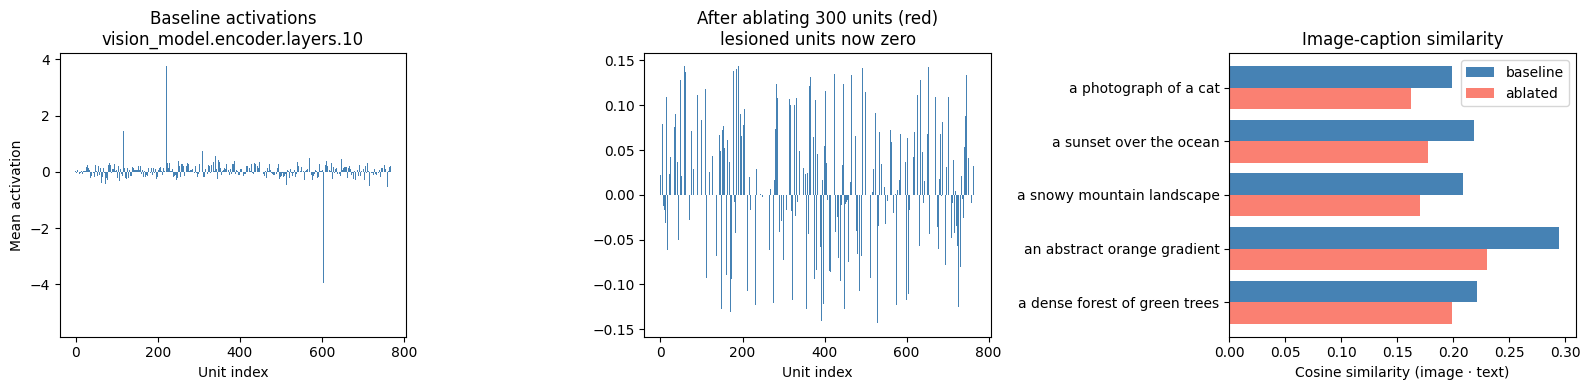

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

hidden_dim = activations['baseline'].shape[-1]
mean_baseline = activations['baseline'].mean(axis=(0, 1))
mean_ablated = activations['ablated'].mean(axis=(0, 1))

# Panel 1 — baseline
axes[0].bar(range(hidden_dim), mean_baseline, color='steelblue', width=1.0)
axes[0].set_title('Baseline activations\n' + TARGET_LAYER_PATH)
axes[0].set_xlabel('Unit index')
axes[0].set_ylabel('Mean activation')

# Panel 2 — ablated, with lesioned units in red
ablated_mask = np.zeros(hidden_dim, dtype=bool)
ablated_mask[units_to_ablate] = True
colors = np.where(ablated_mask, 'red', 'steelblue')
axes[1].bar(range(hidden_dim), mean_ablated, color=colors, width=1.0)
axes[1].set_title(f'After ablating {TOP_K} units (red)\n'
                  f'lesioned units now zero')
axes[1].set_xlabel('Unit index')

# Panel 3 — behavioral effect (cosine similarity per caption)
y = np.arange(len(captions))
width = 0.4
axes[2].barh(y - width/2, baseline_sims, height=width,
             label='baseline', color='steelblue')
axes[2].barh(y + width/2, ablated_sims, height=width,
             label='ablated', color='salmon')
axes[2].set_yticks(y)
axes[2].set_yticklabels([c[:34] for c in captions])
axes[2].set_xlabel('Cosine similarity (image · text)')
axes[2].set_title('Image-caption similarity')
axes[2].legend()
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

## 7. Reset and verify restoration

`model.reset()` removes all active perturbations. The model should produce identical baseline outputs.

In [8]:
bs_model.reset()
assert len(bs_model._active_perturbations) == 0

h = target_layer.register_forward_hook(make_capture('restored'))
with torch.no_grad():
    restored_out = clip_model(**inputs)
h.remove()
restored_sims = cosine_sims(restored_out)

for cap, s_orig, s_restored in zip(captions, baseline_sims, restored_sims):
    print(f'  baseline={s_orig:+.3f}  restored={s_restored:+.3f}  {cap}')

assert np.allclose(baseline_sims, restored_sims, atol=1e-5), \
    'reset did not restore baseline outputs'
print('\nReset successfully restored the model to baseline.')

  baseline=+0.199  restored=+0.199  a photograph of a cat
  baseline=+0.218  restored=+0.218  a sunset over the ocean
  baseline=+0.208  restored=+0.208  a snowy mountain landscape
  baseline=+0.295  restored=+0.295  an abstract orange gradient
  baseline=+0.221  restored=+0.221  a dense forest of green trees

Reset successfully restored the model to baseline.


## What this enables

- **Causal contribution measurement**: `(score baseline) − (score lesioned)` quantifies how much a specific layer/unit set contributes to a benchmark.
- **Honarmand-style induced dyslexia**: ablate VWFA-analog units in a VLM, re-score on ROAR, watch reading accuracy drop.
- **2×2 mechanism designs**: cross `path` (readout vs generation) with `state` (baseline vs lesioned) to localize where in the model the relevant computation lives.
- **Selective undo**: `process(StateChange(kind='reset', handle_id=...))` removes one perturbation at a time, so multi-region lesion experiments are expressible.

All from a single `BrainScoreModel` registration. No subclassing, no benchmark-side branching — just `process(StateChange(...))`.